In [1]:
#подключаем библетоеки

#cuda or cpu

#параметры

#класс датасета(мейби)

#путь выгрузи

#Разбивка датасета

#создали датасеты

# создаем загрузчики

#Обучение
# подготовка
# 1. Задать модель - nn.Module
 #заменить классификатор для предобоученной модели

# 2. Задать функцию потерь 

# 3. Задать оптимизатор - 


# поместить модель и метрику на GPU

# создать вспомогательные списки для данных
# н-р, лосс на каждой итераций

# н-р, общий лосс

# н-р, accuracy



# для каждой эпохи

  # для каждой части датасета
  
    # ЭТАП ОБУЧЕНИЯ
    # мы переводим модель в режим обучения
   
    # ОБНУЛЯЕМ градиенты у оптимизатора
  
    # пропускам данные через модель
  
    # выравняем выходы в одномерный тензор
   
    # считаем лосс
    
    # делаем шаг в обратном направлении
    
    # собираем лоссы
    
    # делаем шаг оптимизатора
   
  # собираем средний лосс
  
  #добавить подобное
  #   if (i + 1) % 100 == 0:
    #        print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
      #            .format(epoch + 1, num_epochs, i + 1, total_step, loss.item(),
     #                     (correct / total) * 100))
 
  # ШАГ ВАЛИДАЦИИ (тестрирование)
 
    # режим инференса или валидации, тестирования
   
    # обязательно добавить no грал
  
      # считаем вероятности
      
      # ситаем метрику

# Сохраняем модель

#график

# выводим картинки с результатом правильным и итговымм
# как-то считать вероятность в целом

In [2]:
import pickle
import math
import numpy as np
import pandas as pd
from skimage import io
from matplotlib import colors, pyplot as plt
%matplotlib inline

from PIL import Image
from pathlib import Path
import torchvision

import torch
import torch.nn as nn
from torchvision import transforms, models
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import f1_score
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm_notebook

import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

import os

# importing Libraries 
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc 

import numpy 
import gc

In [3]:

gc.collect()
torch.cuda.empty_cache()

In [6]:
#параметры
#устанавливаем тренировочные гиперпараметры
num_epochs = 10 #эпохи
num_classes = 2#классы
batch_size = 100#батчи
batch_size_val = 100
learning_rate = 0.003 #время обучения

In [8]:
#создали датасеты

class SteganographyDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        img_path = os.path.join(self.root_dir, self.annotations.iloc[index, 0])
        image = Image.open(img_path)
        y_label = torch.tensor(int(self.annotations.iloc[index, 1]))

        if self.transform:
            image = self.transform(image)

        return (image, y_label)

In [9]:
#Путь выгрузки
#путь
ROOT_DIR = Path('/kaggle/input/data-set-koch-csharp/directory')
CSV_DIR = Path('/kaggle/input/data-set-koch-csharp/dataset.csv')


In [10]:
#Разбивка датасета
train_size=7200
test_size=1800

In [13]:
dataset=SteganographyDataset(csv_file=CSV_DIR,root_dir=ROOT_DIR,transform = transforms.ToTensor())#transforms.ToTensor()

In [18]:
# создаем загрузчики
train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(dataset=train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_set, batch_size=batch_size_val, shuffle=True)

In [20]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_CPU = torch.device("cpu")

In [21]:
c = torch.cuda.is_available()
print(DEVICE)

cuda


In [22]:
#Обучение
# подготовка
# 1. Задать модель - nn.Module
#заменить классификатор для предобоученной модели
# 1. Задать модель - nn.Module
#n_classes = len(np.unique(train_val_labels))
#model = models.efficientnet_b2(weights='DEFAULT')
#num_features = 1408
#model.classifier = nn.Sequential(
 #                       nn.Linear(num_features, 256),
 #                       nn.ReLU(),
 #                       nn.Linear(256, 23)
#)

model = torchvision.models.resnet50(weights="DEFAULT")

model.classifier = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, num_classes)
)

# поместить модель и метрику на GPU
model.to(DEVICE)

#print("We will classify {} labels\n".format(n_classes))
print("We changed the last classifier layer with:\n", model.classifier)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s] 


We changed the last classifier layer with:
 Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=2, bias=True)
)


In [24]:
# 2. Задать функцию потерь 
# выбираем функцию потерь
#зависит от функции активации!!!!!!!!!!!!!!!!!!!!!!
loss_func = torch.nn.CrossEntropyLoss() #!!!!!!!!!!!!!!!!!!!!!!!!!

# 3. Задать оптимизатор 
# выбираем алгоритм оптимизации 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) #может быть ошиька


In [25]:
# создать вспомогательные списки для данных
# н-р, лосс на каждой итераций
losses_train = []
# н-р, общий лосс
total_loss = []
# н-р, accuracy
acc_train = []
# н-р, accuracy
total_acc_train = []
# н-р, accuracy

# н-р, precision
prec_train = []
# н-р, precision
total_prec_train = []
# н-р, precision

# н-р, recall
recall_train = []
# н-р, recall
total_recall_train = []
# н-р, recall

# н-р, recall
f1_train = []
# н-р, recall
total_f1_train = []
# н-р, recall


acc_test = []



#------------------------------------------------------ ВАЛИДАЦИЯ ---------------------------------------------
losses_val = []
total_loss_val = []

# собираем  acc
total_acc_val = []
# собираем Precision
total_prec_val = []
# собираем   Recall
total_recall_val = []
# собираем  F1-Score
total_f1_val = []

#----------------------------------
total_los_train22 = []
total_los_val22 = []

In [26]:
#ПРОВЕРКА СКРИПТА
#С метриками написанными вручную
# Для каждой эпохи
for epoch in tqdm_notebook(range(num_epochs)):
    #подсчет acc
    num_correct = 0
    num_samples = 0
    #подсчет метрик 
    TP = 0
    FP = 0
    FN = 0
    loss_train = 0 
     # для каждой части датасета
    for iterat,batch in tqdm_notebook(enumerate(train_loader)):
        #print("iter"+str(iterat)+"\n")
        # ЭТАП ОБУЧЕНИЯ
        # мы переводим модель в режим обучения
        model.train()
        #получаем текущий батч
        X_batch, y_batch = batch #X_b - тензор картинки, y_b - класс
        # ОБНУЛЯЕМ градиенты у оптимизатора
        optimizer.zero_grad()
        # Прямое распространение - пропускам данные через модель
        y_prediction = model(X_batch.to(DEVICE)) # полученное предсказанное значение
        
        # выравняем выходы в одномерный тензор
        # скорее всего в сверточной не надо,хз разберемся
        
        # Вычисление функции потерь
        # считаем лосс
        loss = loss_func(y_prediction,y_batch.to(DEVICE))
        # Обратное распространение
        # делаем шаг в обратном направлении
        loss.backward()
        # делаем шаг оптимизатора
        optimizer.step()
        # собираем лоссы
        #print("Тренировачный лосс \n")
        #print(loss.detach().cpu().numpy().item())
        losses_train.append(loss.detach().cpu().numpy().item())
        loss_train = loss_train + loss.detach().cpu().numpy().item()
        # перевод в нормльное значение
        
       # print(y_batch.size())
       # print("\n")
        #print(y_prediction.size())
        _, predictions = y_prediction.max(1)
        #собираем  acc
        num_correct += (predictions == y_batch.to(DEVICE)).sum()
        num_samples += predictions.size(0)
        #подсчет параметров для метрик
        TP = TP + ((predictions.to(DEVICE) == 1) & (y_batch.to(DEVICE) == 1)).sum().item()
        FP = FP + ((predictions.to(DEVICE) == 1) & (y_batch.to(DEVICE) == 0)).sum().item()
        FN = FN + ((predictions.to(DEVICE) == 0) & (y_batch.to(DEVICE) == 1)).sum().item()
        
        del X_batch
        del y_batch
        del predictions
        gc.collect()
        torch.cuda.empty_cache()
        
        """
        X_batch.detach()
        X_batch.grad = None
    
        y_batch.detach()
        y_batch.grad = None
       
        predictions.detach()
        predictions.grad = None
        """
       
   
    
    #Валидация
    
    #tensor.detach()
    #tensor.grad = None
    #tensor.storage().resize_(0)
    
    #подсчет acc
    num_correct_val = 0
    num_samples_val = 0
    #подсчет метрик 
    TP_val = 0
    FP_val = 0
    FN_val = 0
    loss_val = 0 
   
    # model.to(DEVICE_CPU)
    gc.collect()
    torch.cuda.empty_cache()
    #model.to(DEVICE)
    
    
         # Optional when not using Model Specific layer
    for iterat,batch in tqdm_notebook(enumerate(test_loader)):
        #print("iter"+str(iterat)+"\n")
        model.eval()
        with torch.no_grad():
            X_batch, y_batch = batch
            
            y_prediction = model(X_batch.to(DEVICE))
            loss = loss_func(y_prediction,y_batch.to(DEVICE))
            #print("Тренировачный лосс \n")
            #print(loss.detach().cpu().numpy().item())
            #losses_val.append(loss.detach().cpu().numpy().item())
            loss_val = loss_val + loss.detach().cpu().numpy().item()
            _, predictions = y_prediction.max(1)
            #собираем  acc
            num_correct_val += (predictions == y_batch.to(DEVICE)).sum()
            num_samples_val += predictions.size(0)
        
            TP_val = TP_val + ((predictions.to(DEVICE) == 1) & (y_batch.to(DEVICE) == 1)).sum().item()
            FP_val = FP_val + ((predictions.to(DEVICE) == 1) & (y_batch.to(DEVICE) == 0)).sum().item()
            FN_val = FN_val + ((predictions.to(DEVICE) == 0) & (y_batch.to(DEVICE) == 1)).sum().item()
        
        del X_batch
        del y_batch
        del predictions
        gc.collect()
        torch.cuda.empty_cache()
        """
        X_batch.detach()
        X_batch.grad = None
​
        y_batch.detach()
        y_batch.grad = None
        
        predictions.detach()
        predictions.grad = None
        """
       
    # Тренировчные
    
    # собираем средний лосс
    #total_loss.append(np.mean(losses_train))
    total_loss.append(loss_train/len(train_loader))
    
    #считаем acc
    acc=float(num_correct)/float(num_samples)
    
    #cчитаем precision
    precision = TP / (TP + FP) if TP + FP > 0 else 0
    #cчитаем recall
    recall = TP / (TP + FN) if TP + FN > 0 else 0
    #cчитем f1
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
   
    # собираем  acc
    total_acc_train.append( acc)
    # собираем Precision
    total_prec_train.append(precision)
    # собираем   Recall
    total_recall_train.append(recall)
    # собираем  F1-Score
    total_f1_train.append( f1)
    total_los_train22.append(loss_train/len(train_loader))
    
    print(f'Валидационный тест датасет')
    #print(f'{epoch+1},\t loss: {losses_train[-1]}')
    print(f'{epoch+1},\t loss: {loss_train/len(train_loader)}')
    print(f'acc: {acc}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1}')
    
    # Валидационные
    
    # собираем средний лосс
    #total_loss_val.append(np.mean(losses_val))
    total_loss_val.append(loss_val/len(test_loader))
    #считаем acc
    acc=float(num_correct_val)/float(num_samples_val)
    
    #cчитаем precision
    precision = TP_val / (TP_val + FP_val) if TP_val + FP_val > 0 else 0
    #cчитаем recall
    recall = TP_val / (TP_val + FN_val) if TP_val + FN_val > 0 else 0
    #cчитем f1
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # собираем  acc
    total_acc_val.append( acc)
    # собираем Precision
    total_prec_val.append(precision)
    # собираем   Recall
    total_recall_val.append(recall)
    # собираем  F1-Score
    total_f1_val.append( f1)
    
    total_los_val22.append(loss_val/len(test_loader))
    
    print(f'Валидационный датасет')
    #print(f'{epoch+1},\t loss: {total_loss_val[-1]}') loss_val/len(test_loader)
    print(f'{epoch+1},\t loss: {loss_val/len(test_loader)}')
    print(f'acc: {acc}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1}')

  0%|          | 0/10 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Валидационный тест датасет
1,	 loss: 0.5296369544230402
acc: 0.8234722222222223
Precision: 0.8328683035714286
Recall: 0.8446519524617997
F1 Score: 0.8387187412194437
Валидационный датасет
1,	 loss: 3.6065299113591514
acc: 0.6155555555555555
Precision: 0.9949494949494949
Recall: 0.22184684684684686
F1 Score: 0.36279926335174956


0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

Валидационный тест датасет
9,	 loss: 0.00772600182926908
acc: 0.9975
Precision: 0.9975083056478405
Recall: 0.9975083056478405
F1 Score: 0.9975083056478405
Валидационный датасет
9,	 loss: 0.2431577659315533
acc: 0.9105555555555556
Precision: 0.8465204957102002
Recall: 1.0
F1 Score: 0.9168817759421786


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Валидационный тест датасет
10,	 loss: 0.01116460965757445
acc: 0.9955555555555555
Precision: 0.9952960708356392
Recall: 0.9958471760797342
F1 Score: 0.9955715471907002
Валидационный датасет
10,	 loss: 0.013639797584295997
acc: 0.9961111111111111
Precision: 0.9932810750279956
Recall: 0.9988738738738738
F1 Score: 0.9960696238068502


In [26]:
torch.save(model.state_dict(), 'the_best_model8_na_vs.pth')

In [27]:
print(f'Тренировачный тест датасет')
#print(f'{epoch+1},\t loss: {losses_train[-1]}')
print("total_loss")
print(total_loss)

print("total_acc_train")
print(total_acc_train)

print("total_prec_train")
print(total_prec_train)

print("total_recall_train")
print(total_recall_train)

print("total_f1_train")
print(total_f1_train)

print(f'Валидационный тест датасет')
#print(f'{epoch+1},\t loss: {losses_train[-1]}')
print("total_loss_val")
print(total_loss_val)

print("total_acc_val")
print(total_acc_val)

print("total_recall_val")
print(total_recall_val)

print("total_prec_val")
print(total_prec_val)

print("total_f1_val")
print(total_f1_val)

Тренировачный тест датасет
total_loss
[0.5296369544230402, 0.07735027026178108, 0.03789311282000401, 0.02226859374705883, 0.017797549051465467, 0.009822710241855425, 0.009336257563998314, 0.009935131643639275, 0.00772600182926908, 0.01116460965757445]
total_acc_train
[0.8234722222222223, 0.9715277777777778, 0.9858333333333333, 0.9905555555555555, 0.9934722222222222, 0.9970833333333333, 0.9961111111111111, 0.9956944444444444, 0.9975, 0.9955555555555555]
total_prec_train
[0.8328683035714286, 0.9717529770146773, 0.984271523178808, 0.9905869324473976, 0.9947266167082986, 0.9975062344139651, 0.9966740576496674, 0.9958460260315702, 0.9975083056478405, 0.9952960708356392]
total_recall_train
[0.8446519524617997, 0.971483942414175, 0.9875415282392026, 0.9905869324473976, 0.9922480620155039, 0.9966777408637874, 0.9955703211517165, 0.9955703211517165, 0.9975083056478405, 0.9958471760797342]
total_f1_train
[0.8387187412194437, 0.9716184410909594, 0.9859038142620232, 0.9905869324473976, 0.993485793

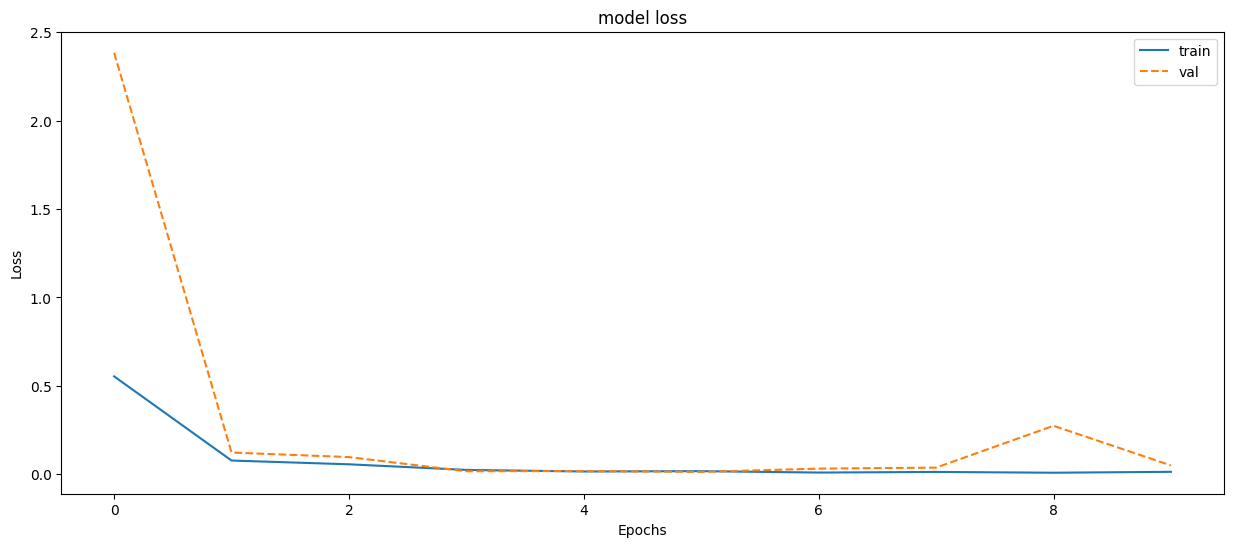

In [19]:
plt.figure(figsize=(15, 6))
# Первый график
plt.plot(range(len(total_loss)),
         total_loss,
         linestyle="-",
         label="train"
         )

# Второй график
plt.plot(range(len(total_loss_val)),
         total_loss_val,
         linestyle="--",
         label="val"
         )
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("model loss")
plt.legend()
plt.show()

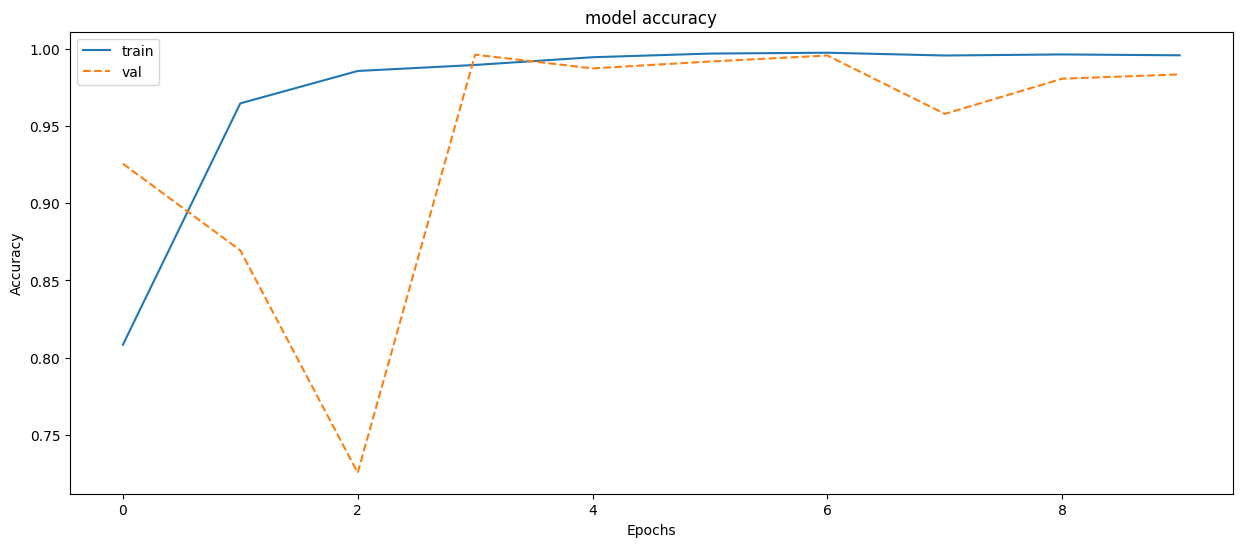

In [19]:
plt.figure(figsize=(15, 6))
plt.plot(range(len(total_acc_train)),
         total_acc_train,
         linestyle="-",
         label="train"
         #marker="o"
         )
plt.plot(range(len(total_acc_val)),
         total_acc_val,
         linestyle="--",
         label="val",
         #marker="o"
         )
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("model accuracy")
plt.legend()
plt.show()

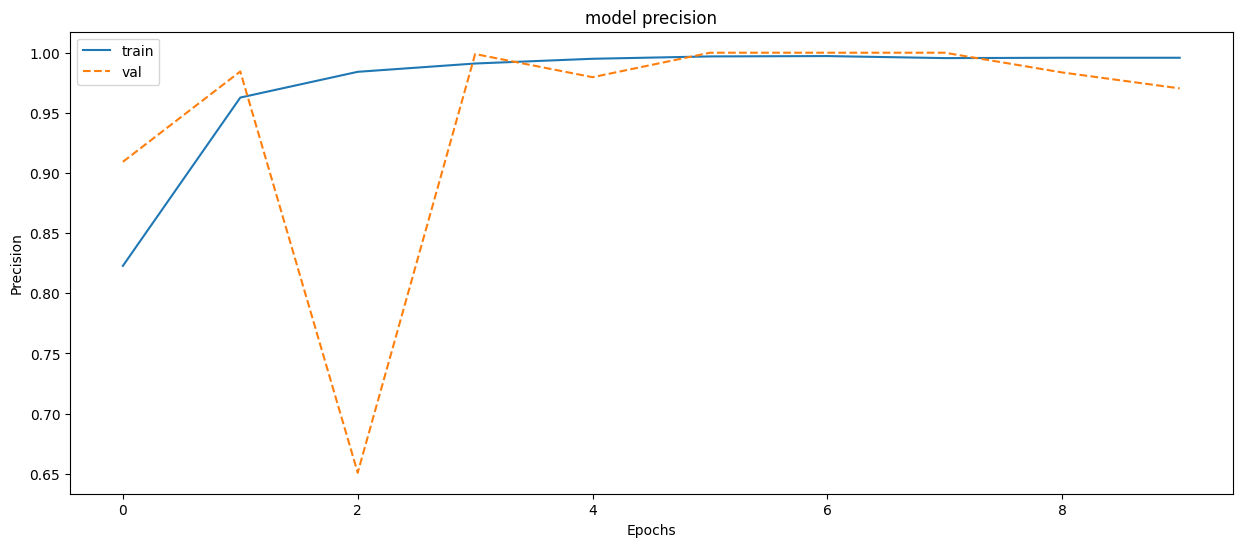

In [20]:
plt.figure(figsize=(15, 6))
plt.plot(range(len(total_prec_train)),
         total_prec_train,
         linestyle="-",
         label="train"
         )
plt.plot(range(len(total_prec_val)),
         total_prec_val,
         linestyle="--",
         label="val"
         )
plt.xlabel("Epochs")
plt.ylabel("Precision")
plt.title("model precision")
plt.legend()
plt.show()

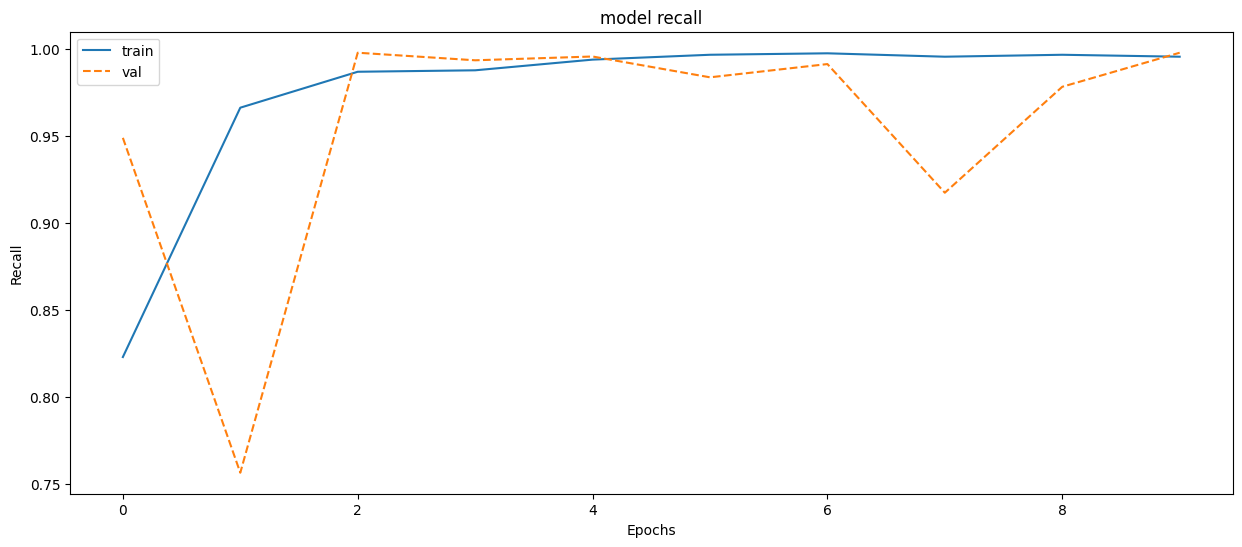

In [21]:
plt.figure(figsize=(15, 6))
plt.plot(range(len(total_recall_train)),
         total_recall_train,
         linestyle="-",
         label="train"
         )
plt.plot(range(len(total_recall_val)),
         total_recall_val,
         linestyle="--",
         label="val"
         )
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.title("model recall")
plt.legend()
plt.show()

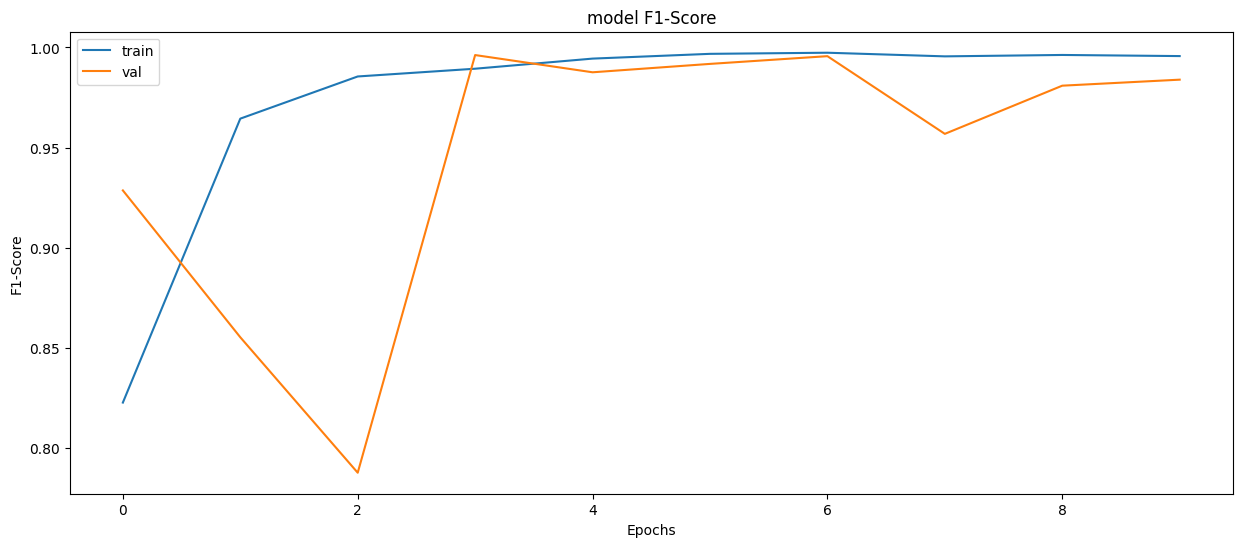

In [22]:
plt.figure(figsize=(15, 6))
plt.plot(range(len(total_f1_train)),
         total_f1_train,
         linestyle="-",
         label="train"
         )
plt.plot(range(len(total_f1_val)),
         total_f1_val,
         linestyle="-",
         label="val"
         )
plt.xlabel("Epochs")
plt.ylabel("F1-Score")
plt.title("model F1-Score")
plt.legend()
plt.show()

In [23]:
def check_accuracy(loader, model):
    num_correct = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=DEVICE)
            y = y.to(device=DEVICE)
            
            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

        print(
            f"Got {num_correct} / {num_samples} with accuracy {float(num_correct)/float(num_samples)*100:.2f}"
        )

    model.train()

In [35]:
print("Checking accuracy on Training Set")
check_accuracy(train_loader, model)

print("Checking accuracy on Test Set")
check_accuracy(test_loader, model)

Checking accuracy on Training Set
Got 7193 / 7200 with accuracy 99.90
Checking accuracy on Test Set
Got 1793 / 1800 with accuracy 99.61
